# 03 — Batsman Analysis

**Goal**: Build rich batsman profiles and a similarity matrix.

**Input**: `data/final_processed_data.csv`

**Outputs**:
- `data/batsman_profiles.csv` — per-batsman stats
- `data/batsman_similarity.csv` — cosine similarity matrix

**Analysis**:
1. Core batting metrics (runs, SR, average, boundary%, dismissal rate)
2. Performance vs each bowler style
3. Performance vs each pitch zone
4. Adaptability index (consistency across bowling styles)
5. Cosine similarity matrix from pitch-zone scoring patterns
6. Visualisations: top-N batsmen, similarity, heatmaps

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_OUT     = os.path.join(PROJECT_ROOT, 'data')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv(os.path.join(DATA_OUT, 'final_processed_data.csv'))

# Ensure correct types
for col in ['isFour', 'isSix', 'isWicket']:
    df[col] = df[col].astype(int)
df['run']        = pd.to_numeric(df['run'], errors='coerce').fillna(0)
df['isBoundary'] = ((df['isFour'] == 1) | (df['isSix'] == 1)).astype(int)

# Valid deliveries (exclude wides and no-balls for SR / dismissal rate)
df['is_valid'] = ((df['wides'] == 0) & (df['noballs'] == 0)).astype(int)

print(f'Loaded {len(df):,} deliveries for {df["Full Name"].nunique()} batsmen')

Loaded 33,029 deliveries for 462 batsmen


## 2. Core Batting Metrics

In [3]:
def batsman_metrics(grp):
    valid        = grp[grp['is_valid'] == 1]
    runs         = grp['run'].sum()
    balls        = len(valid)
    wickets      = grp['isWicket'].sum()
    fours        = grp['isFour'].sum()
    sixes        = grp['isSix'].sum()
    boundaries   = grp['isBoundary'].sum()
    dot_balls    = (valid['run'] == 0).sum()
    strike_rate  = (runs / balls * 100)    if balls > 0 else 0
    average      = (runs / wickets)        if wickets > 0 else np.nan
    dismissal_rt = (balls / wickets)       if wickets > 0 else np.nan   # balls per dismissal
    boundary_pct = (boundaries / balls * 100) if balls > 0 else 0
    dot_pct      = (dot_balls / balls * 100)  if balls > 0 else 0
    return pd.Series({
        'total_runs': runs, 'balls_faced': balls,
        'total_fours': fours, 'total_sixes': sixes, 'total_boundaries': boundaries,
        'total_wickets': wickets,
        'strike_rate': round(strike_rate, 2),
        'average': round(average, 2) if not np.isnan(average) else 0,
        'dismissal_rate': round(dismissal_rt, 2) if not np.isnan(dismissal_rt) else 0,
        'boundary_pct': round(boundary_pct, 2),
        'dot_ball_pct': round(dot_pct, 2)
    })

profiles = df.groupby('Full Name').apply(batsman_metrics).reset_index()

# Minimum balls threshold for meaningful stats
MIN_BALLS = 30
profiles_full = profiles.copy()           # keep all for similarity
profiles      = profiles[profiles['balls_faced'] >= MIN_BALLS].copy()

print(f'Batsmen with ≥{MIN_BALLS} balls: {len(profiles)} / {len(profiles_full)}')
profiles.sort_values('strike_rate', ascending=False).head(10)

Batsmen with ≥30 balls: 248 / 462


C:\Users\yaswa\AppData\Local\Temp\ipykernel_9348\4063554313.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = df.groupby('Full Name').apply(batsman_metrics).reset_index()


,Full Name,total_runs,balls_faced,total_fours,total_sixes,total_boundaries,total_wickets,strike_rate,average,dismissal_rate,boundary_pct,dot_ball_pct
0,AB de Villiers,117.0,61.0,5.0,9.0,14.0,3.0,191.80,39.00,20.33,22.95,24.59
378,Shahid Afridi,89.0,47.0,6.0,7.0,13.0,4.0,189.36,22.25,11.75,27.66,34.04
182,Jean-Paul Duminy,87.0,48.0,5.0,4.0,9.0,0.0,181.25,0.00,0.00,18.75,8.33
437,Travis Head,80.0,45.0,9.0,5.0,14.0,2.0,177.78,40.00,22.50,31.11,44.44
326,Phil Salt,62.0,35.0,6.0,4.0,10.0,3.0,177.14,20.67,11.67,28.57,37.14
397,Shoaib Malik,198.0,112.0,11.0,11.0,22.0,3.0,176.79,66.00,37.33,19.64,17.86
4,Aaron Jones,152.0,87.0,6.0,13.0,19.0,1.0,174.71,152.00,87.00,21.84,39.08
172,James Neesham,166.0,96.0,5.0,9.0,14.0,6.0,172.92,27.67,16.00,14.58,25.00
29,Andre Russell,181.0,105.0,18.0,8.0,26.0,7.0,172.38,25.86,15.00,24.76,36.19
244,Marcus Stoinis,316.0,186.0,18.0,20.0,38.0,5.0,169.89,63.20,37.20,20.43,27.42


## 3. Performance vs Bowler Style

In [4]:
# Avg runs per ball faced vs each bowling style (pivot)
vs_style = df.groupby(['Full Name', 'Bowler_Bowling_Style'])['run'].mean().unstack().fillna(0)
vs_style.columns = ['vs_' + c.replace(' ', '_').replace(',', '').replace('-', '_') for c in vs_style.columns]
profiles = profiles.merge(vs_style, on='Full Name', how='left')
print('vs-style columns added:', [c for c in profiles.columns if c.startswith('vs_')][:5], '...')

vs-style columns added: ['vs_left_arm_fast', 'vs_left_arm_fast_medium', 'vs_left_arm_medium', 'vs_left_arm_mediumslow_left_arm_orthodox', 'vs_left_arm_medium_fast'] ...


## 4. Phase-wise Performance

In [5]:
def phase(o):
    if o <= 6:  return 'powerplay'
    if o <= 15: return 'middle'
    return 'death'
df['match_phase'] = df['oversActual'].apply(phase)

phase_runs = df.groupby(['Full Name', 'match_phase'])['run'].mean().unstack().fillna(0)
phase_runs.columns = ['avg_runs_' + c for c in phase_runs.columns]
profiles = profiles.merge(phase_runs, on='Full Name', how='left')
profiles[['avg_runs_powerplay','avg_runs_middle','avg_runs_death']].describe().round(2)

,avg_runs_powerplay,avg_runs_middle,avg_runs_death
count,248.00,248.00,248.00
mean,0.76,1.06,1.15
std,0.51,0.39,0.75
min,0.00,0.00,0.00
25%,0.25,0.87,0.58
50%,0.89,1.10,1.30
75%,1.14,1.26,1.64
max,1.78,2.20,4.33


## 5. Adaptability Index

Measures how *consistent* a batsman is across different bowler styles.
- Computed as the coefficient of variation (std / mean) of run-rates across bowling styles.
- **Lower CV** = more consistent / adaptable against all styles.
- Normalised to a 0–1 score where **1 = most adaptable**.

In [6]:
vs_cols = [c for c in profiles.columns if c.startswith('vs_')]

vs_matrix = profiles[vs_cols].values
row_means  = vs_matrix.mean(axis=1, keepdims=True)
row_stds   = vs_matrix.std(axis=1)
# CV = std / mean; protect against zero mean
cv = np.where(row_means.ravel() > 0, row_stds / row_means.ravel(), 1.0)
# Invert and normalise so high score = adaptable
adapt_raw  = 1 / (1 + cv)
scaler     = MinMaxScaler()
profiles['adaptability_index'] = scaler.fit_transform(adapt_raw.reshape(-1, 1)).ravel().round(3)

profiles['adaptability_label'] = pd.cut(
    profiles['adaptability_index'],
    bins=[-0.001, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)

print('Adaptability distribution:')
print(profiles['adaptability_label'].value_counts())
profiles[['Full Name','adaptability_index','adaptability_label']].sort_values('adaptability_index', ascending=False).head(10)

Adaptability distribution:
adaptability_label
Medium    118
High       76
Low        54
Name: count, dtype: int64


,Full Name,adaptability_index,adaptability_label
134,Max O'Dowd,1.000,High
166,Pathum Nissanka,0.986,High
22,Babar Azam,0.934,High
146,Mohammad Nabi,0.932,High
66,George Munsey,0.930,High
140,Mitchell Marsh,0.916,High
160,Nicholas Pooran,0.896,High
132,Matthew Cross,0.888,High
97,KL Rahul,0.886,High
115,Litton Das,0.880,High


## 6. Consistency Index

Standard-deviation of run output across deliveries — lower std means more consistent scorer.

In [7]:
run_std    = df.groupby('Full Name')['run'].std().rename('run_std').fillna(0)
profiles   = profiles.merge(run_std, on='Full Name', how='left')
profiles['consistency_index'] = (profiles['average'] / (profiles['run_std'] + 1e-6)).round(3)
profiles['consistency_index'] = profiles['consistency_index'].replace([np.inf, -np.inf], 0)
print('Consistency index range:', profiles['consistency_index'].min(), '–', profiles['consistency_index'].max())

Consistency index range: 0.0 – 73.866


## 7. Save Batsman Profiles

In [8]:
out_path = os.path.join(DATA_OUT, 'batsman_profiles.csv')
profiles.to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(profiles)} batsmen × {len(profiles.columns)} columns)')

Saved → c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project\data\batsman_profiles.csv  (248 batsmen × 40 columns)


## 8. Batsman Similarity Matrix

In [9]:
# Build pitch-zone scoring matrix (length × line avg runs)
df['pitch_zone'] = df['pitchLength'] + '__' + df['pitchLine']
zone_matrix = df.groupby(['Full Name', 'pitch_zone'])['run'].mean().unstack().fillna(0)

# Only keep batsmen with MIN_BALLS or more
qualified = profiles['Full Name'].tolist()
zone_matrix = zone_matrix[zone_matrix.index.isin(qualified)]

# Scale and compute cosine similarity
zone_scaled = MinMaxScaler().fit_transform(zone_matrix)
sim_matrix  = cosine_similarity(zone_scaled)
sim_df      = pd.DataFrame(sim_matrix, index=zone_matrix.index, columns=zone_matrix.index)

sim_out = os.path.join(DATA_OUT, 'batsman_similarity.csv')
sim_df.to_csv(sim_out)
print(f'Similarity matrix saved → {sim_out}  shape: {sim_df.shape}')

Similarity matrix saved → c:\Users\yaswa\OneDrive\Desktop\projects\artificial intelligence project\data\batsman_similarity.csv  shape: (248, 248)


In [10]:
def find_similar_batsmen(name, top_n=5):
    """Return top-N most similar batsmen to `name`."""
    if name not in sim_df.index:
        close = [n for n in sim_df.index if name.lower() in n.lower()]
        print(f'Not found. Possible matches: {close[:5]}')
        return None
    return sim_df[name].sort_values(ascending=False).iloc[1:top_n+1]

# Example
result = find_similar_batsmen('Virat Kohli')
if result is not None:
    print(result)
    fig = px.bar(x=result.index, y=result.values,
                 title='Top-5 Similar Batsmen to Virat Kohli',
                 labels={'x': 'Batsman', 'y': 'Similarity Score'},
                 color=result.values, color_continuous_scale='Blues',
                 text=result.round(3).values)
    fig.update_traces(textposition='outside')
    fig.update_layout(coloraxis_showscale=False)
    fig.show()

Full Name
Martin Guptill     0.825680
George Munsey      0.817938
Aaron Finch        0.803183
Mohammad Rizwan    0.802625
David Wiese        0.796598
Name: Virat Kohli, dtype: float64


## 9. Visualisations

In [11]:
# ── Top 15 batsmen by Strike Rate (min 100 balls) ────────────────────────────
top_sr = profiles[profiles['balls_faced'] >= 100].nlargest(15, 'strike_rate')

fig = px.bar(top_sr, x='Full Name', y='strike_rate',
             color='boundary_pct', color_continuous_scale='YlOrRd',
             title='Top 15 Batsmen by Strike Rate (min 100 balls)',
             text=top_sr['strike_rate'].round(1),
             labels={'strike_rate': 'Strike Rate', 'boundary_pct': 'Boundary %'})
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-35)
fig.show()

In [12]:
# ── Top 15 by Average ─────────────────────────────────────────────────────────
top_avg = profiles[profiles['balls_faced'] >= 100].nlargest(15, 'average')

fig = px.bar(top_avg, x='Full Name', y='average',
             color='strike_rate', color_continuous_scale='Teal',
             title='Top 15 Batsmen by Average (min 100 balls)',
             text=top_avg['average'].round(1),
             labels={'average': 'Batting Average', 'strike_rate': 'SR'})
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-35)
fig.show()

In [13]:
# ── Strike Rate vs Average scatter ───────────────────────────────────────────
plot_df = profiles[profiles['balls_faced'] >= 100].copy()

fig = px.scatter(
    plot_df, x='average', y='strike_rate',
    size='total_runs', color='boundary_pct',
    hover_name='Full Name',
    color_continuous_scale='RdYlGn',
    title='Batting Average vs Strike Rate (bubble = total runs, colour = boundary %)',
    labels={'average': 'Batting Average', 'strike_rate': 'Strike Rate', 'boundary_pct': 'Bdry %'}
)
# Quadrant lines
avg_sr  = plot_df['strike_rate'].median()
avg_avg = plot_df['average'].median()
fig.add_hline(y=avg_sr,  line_dash='dot', line_color='gray', annotation_text='Median SR')
fig.add_vline(x=avg_avg, line_dash='dot', line_color='gray', annotation_text='Median Avg')
fig.show()

In [14]:
# ── Adaptability vs Strike Rate ───────────────────────────────────────────────
fig = px.scatter(
    plot_df, x='adaptability_index', y='strike_rate',
    color='adaptability_label',
    hover_name='Full Name',
    title='Adaptability Index vs Strike Rate',
    labels={'adaptability_index': 'Adaptability Index (0=rigid, 1=adaptable)'},
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}
)
fig.show()

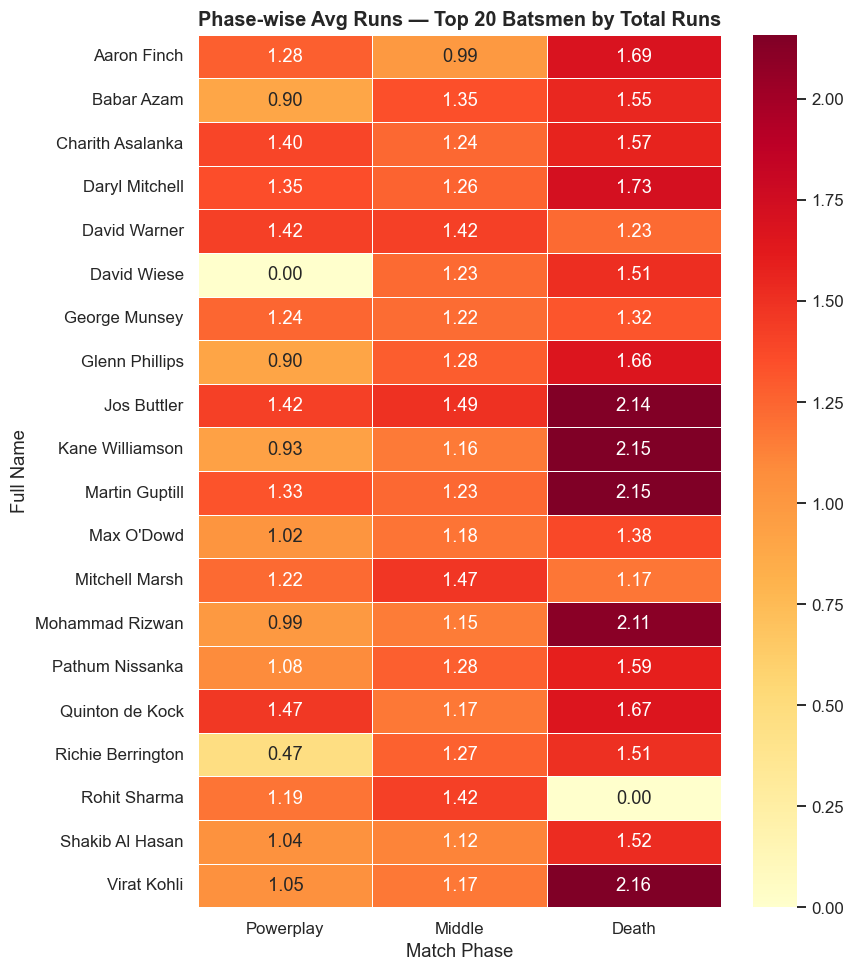

In [15]:
# ── Phase Performance Heatmap for Top 20 batsmen by total runs ────────────────
top20 = profiles.nlargest(20, 'total_runs')['Full Name'].tolist()
phase_pivot = profiles[profiles['Full Name'].isin(top20)].set_index('Full Name')[
    ['avg_runs_powerplay','avg_runs_middle','avg_runs_death']
]
phase_pivot.columns = ['Powerplay', 'Middle', 'Death']

plt.figure(figsize=(8, 9))
sns.heatmap(phase_pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4)
plt.title('Phase-wise Avg Runs — Top 20 Batsmen by Total Runs', fontsize=13, fontweight='bold')
plt.xlabel('Match Phase')
plt.tight_layout()
plt.show()

In [16]:
# ── Dot Ball % by batting style and adaptability ─────────────────────────────
fig = px.box(
    profiles[profiles['balls_faced'] >= 50],
    x='adaptability_label', y='dot_ball_pct',
    color='adaptability_label',
    title='Dot Ball % Distribution by Adaptability Level',
    labels={'adaptability_label': 'Adaptability', 'dot_ball_pct': 'Dot Ball %'},
    color_discrete_map={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}
)
fig.show()

In [17]:
# ── Performance vs different bowling styles for a specific batsman ─────────────
def plot_batsman_vs_styles(name):
    row = profiles[profiles['Full Name'] == name]
    if row.empty:
        print(f'{name} not found')
        return
    vs_data = row[vs_cols].iloc[0].reset_index()
    vs_data.columns = ['Bowling Style', 'Avg Runs/Ball']
    vs_data['Bowling Style'] = vs_data['Bowling Style'].str.replace('vs_', '').str.replace('_', ' ')
    vs_data = vs_data.sort_values('Avg Runs/Ball', ascending=True)
    fig = px.bar(vs_data, y='Bowling Style', x='Avg Runs/Ball',
                 orientation='h', color='Avg Runs/Ball',
                 color_continuous_scale='RdYlGn',
                 title=f'{name} — Avg Runs per Ball vs Bowling Styles')
    fig.update_layout(coloraxis_showscale=False, yaxis_title='')
    fig.show()

plot_batsman_vs_styles('Virat Kohli')
plot_batsman_vs_styles('Rohit Sharma')